In [1]:
import os
import pandas as pd
import numpy as np
import pickle
import boto3
import datetime as dt
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# silence warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
print(f'Latest run date: {dt.datetime.today()}')

Latest run date: 2025-01-07 20:02:55.925236


#### Functions

#### Constants

In [3]:
# project
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_dirname_output = './output'

Project: 20241112-simple-model-test
Task: 13_60_in_720_dl


#### Make output directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import model scores

In [5]:
str_filename = 'df_predictions_grouped.gzip'
str_local_path = f'../03_get_predictions/output/{str_filename}'
df = pd.read_parquet(str_local_path)
# show
df

,accountid,request_datetime,response_model_name,yhat_ml_logistic_scorecard
0,8414009,2024-12-27 00:05:33+00:00,PRESTIGE-GEN-XII,0.094222
1,8436554,2024-12-27 03:24:19+00:00,PRESTIGE-GEN-XII,0.044559
2,8476366,2024-12-27 03:54:36+00:00,PRESTIGE-GEN-XII,0.059646
3,8481198,2024-12-27 01:04:46+00:00,PRESTIGE-GEN-XII,0.067030
4,8485652,2024-12-19 21:30:24+00:00,PRESTIGE-GEN-XII,0.026048
...,...,...,...,...
995,8529168,2024-12-29 06:42:56+00:00,PRESTIGE-GEN-XII,0.080552
996,8529187,2024-12-29 06:49:21+00:00,PRESTIGE-GEN-XII,0.261681
997,8529208,2024-12-29 06:54:36+00:00,PRESTIGE-GEN-XII,0.124613
998,8529346,2024-12-29 08:00:16+00:00,PRESTIGE-GEN-XII,0.222045


#### Import arrays for model scores

In [6]:
list_str_filename = [
    'yhat_ml_logistic_scorecard',
]
dict_arrays_quantiles_model = {}
for str_filename in tqdm(list_str_filename):
    str_filename_new = f'arr_score_quantiles_{str_filename}.pkl'
    str_local_path = f'../03_get_predictions/output/{str_filename_new}'
    arr_quantiles = pickle.load(open(str_local_path, 'rb'))
    dict_arrays_quantiles_model[str_filename] = arr_quantiles

100%|██████████| 1/1 [00:00<00:00, 3057.07it/s]


#### Import array for pricing

In [7]:
str_filename = 'arr_score_quantiles_ecnl.pkl'
str_local_path = f'../04_pricing_distribution/output/{str_filename}'
arr_score_quantile_pricing = pickle.load(open(str_local_path, 'rb'))

#### Interpolate

In [8]:
for key, val in tqdm(dict_arrays_quantiles_model.items()):
    # map quantiles and transform data
    list_mapped_data = list(np.interp(
        x=list(df[key]), 
        xp=val,
        fp=arr_score_quantile_pricing,
    ))
    # assign
    df[f'{key}_mapped_ecnl'] = list_mapped_data
# show
df

100%|██████████| 1/1 [00:00<00:00, 717.59it/s]


,accountid,request_datetime,response_model_name,yhat_ml_logistic_scorecard,yhat_ml_logistic_scorecard_mapped_ecnl
0,8414009,2024-12-27 00:05:33+00:00,PRESTIGE-GEN-XII,0.094222,0.151751
1,8436554,2024-12-27 03:24:19+00:00,PRESTIGE-GEN-XII,0.044559,0.067936
2,8476366,2024-12-27 03:54:36+00:00,PRESTIGE-GEN-XII,0.059646,0.091497
3,8481198,2024-12-27 01:04:46+00:00,PRESTIGE-GEN-XII,0.067030,0.108319
4,8485652,2024-12-19 21:30:24+00:00,PRESTIGE-GEN-XII,0.026048,0.034302
...,...,...,...,...,...
995,8529168,2024-12-29 06:42:56+00:00,PRESTIGE-GEN-XII,0.080552,0.124900
996,8529187,2024-12-29 06:49:21+00:00,PRESTIGE-GEN-XII,0.261681,0.607805
997,8529208,2024-12-29 06:54:36+00:00,PRESTIGE-GEN-XII,0.124613,0.241943
998,8529346,2024-12-29 08:00:16+00:00,PRESTIGE-GEN-XII,0.222045,0.513035


#### Distributions - Scorecard

100%|██████████| 2/2 [00:00<00:00, 28.29it/s]


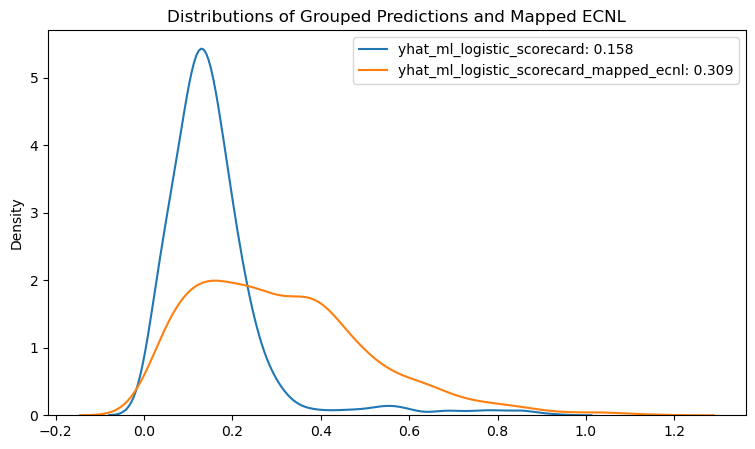

In [9]:
list_cols = [
    'yhat_ml_logistic_scorecard',
    'yhat_ml_logistic_scorecard_mapped_ecnl',
]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('Distributions of Grouped Predictions and Mapped ECNL')
for col in tqdm(list_cols):
    flt_mn = df[col].mean()
    str_label = f'{col}: {flt_mn:0.3f}'
    sns.kdeplot(list(df[col]), label=str_label)
# legend
ax.legend()
# show
plt.show()